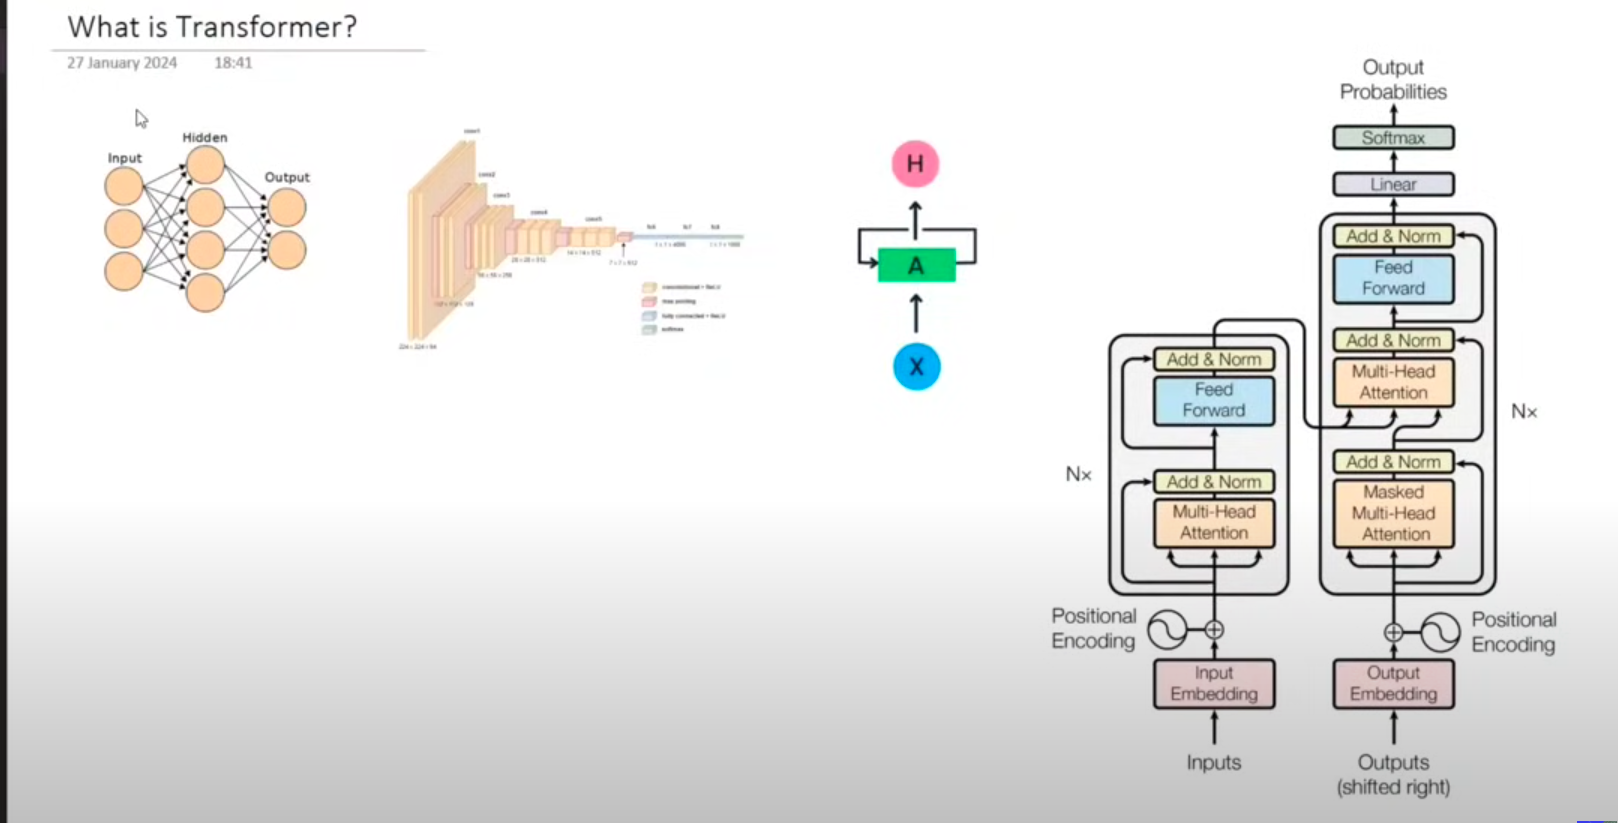

#  Introduction to Transformer

##  NLP Over the Last 50 Years

- **Natural Language Processing (NLP)** focuses on enabling machines to understand and generate human languages (e.g., English, Hindi).
- **Rule-based Systems** (1950s–1990s): Manually coded grammar and linguistic rules (syntax trees, parse rules).
- **Statistical NLP** (1990s–2010): Introduced probabilistic models like **n-grams**, **Hidden Markov Models (HMMs)**.
- **Machine Learning Models**: Algorithms such as **Naive Bayes**, **SVMs**, and **Decision Trees** helped improve tasks like classification and POS tagging.
- **Deep Learning Era**: Neural networks began to dominate NLP after 2013, offering better performance through **representation learning**.
- Challenge: Earlier models lacked a deep understanding of **semantics**, **context**, and **long-term dependencies**.

---

##  Step 1: Recurrent Neural Networks (RNNs)

- RNNs process input sequences **one timestep at a time**, maintaining a **hidden state** to carry context.
- Example: For sentence `"I am going to school"`:


h1 = RNN("I")

h2 = RNN("am", h1)

h3 = RNN("going", h2)

...


- Each word’s output depends on the previous word’s hidden state.

###  Limitations of RNNs:
- **Vanishing gradient problem** in long sequences — older inputs are "forgotten".
- **No parallelization** during training due to sequential nature.
- **Slow training**, especially for long texts.

---

##  Step 2: Long Short-Term Memory (LSTM)

- LSTM is a variant of RNN that introduces **gating mechanisms** to control the flow of information:
- **Forget Gate:** What to forget?
- **Input Gate:** What to remember?
- **Output Gate:** What to output?

- Designed to address long-term dependency issues in RNNs.

###  Benefits:
- Better at capturing **long-range dependencies**.
- Used in many sequence-based tasks (e.g., speech, translation).

###  Limitations:
- Still **sequential**, so training is **slow**.
- **Complex architecture**.
- Struggles with **very long sequences** or hierarchical structures.

---

##  Step 3: Seq2Seq Model (Encoder-Decoder Architecture, 2014)

- Proposed for tasks like **Neural Machine Translation** (e.g., English → French).
- Composed of:
- **Encoder**: Reads input sequence and encodes it into a **fixed-length context vector**.
- **Decoder**: Generates output sentence from that vector.

###  Example:


Input: "I love NLP"

Encoder → context vector (e.g., z)

Decoder(z) → "J'aime le TAL"


###  Problems in Seq2Seq:
- Compressing entire input into a **single fixed-size vector** leads to **information loss**, especially for **long or complex sentences**.
- Model struggles to remember **important tokens** from the beginning of long sequences.
- Context vector bottleneck limits translation quality.

---

##  Step 4: Attention Mechanism (2014)

- Introduced to **overcome the bottleneck** in Seq2Seq models.
- Instead of relying on a single context vector, the **decoder dynamically attends** to different parts of the input sequence at each decoding step.
  
###  Key Idea:
- At each output word generation, compute a **weighted sum** of all encoder hidden states:
  - More **attention weight** is given to relevant words.

###  Benefits:
- Better handling of **long sequences**.
- Improves translation accuracy and alignment between input–output.
- Used in **Bahdanau Attention**, **Luong Attention** variants.

---

##  Step 5: Transformer (2017, Google Brain)

- Introduced in the paper **"Attention is All You Need"**.
- Removes recurrence entirely — uses **Self-Attention** to process entire sequences **in parallel**.

###  Key Components:
- **Multi-Head Self-Attention**: Captures relationships between all tokens at once.
- **Positional Encoding**: Adds sequence order information (since no recurrence).
- **Feed-Forward Layers**, **Residual Connections**, and **Layer Normalization** improve learning stability.

###  Advantages:
- Supports **parallel computation** → faster training.
- **Scales well** to longer texts.
- Forms the basis of powerful models like **BERT**, **GPT**, **T5**, etc.

---

##  Quick Comparison Table

| Model        | Architecture Type      | Key Innovation                  | Limitation                             |
|--------------|------------------------|----------------------------------|----------------------------------------|
| RNN          | Recurrent              | Hidden state memory              | Vanishing gradients, no parallelism    |
| LSTM         | Gated RNN              | Memory cell + gates              | Slow, still sequential                 |
| Seq2Seq      | Encoder–Decoder        | Encodes sentence to context      | Bottleneck in fixed vector             |
| + Attention  | Encoder–Decoder + Attn | Dynamic context vector           | Slower with RNN base                   |
| Transformer  | Fully Attention-based  | Multi-head self-attention        | Requires large data and compute        |

---

##  Summary

- NLP evolved from **rules → statistics → deep learning**.
- Traditional RNN-based models struggle with **long-term dependencies**.
- Seq2Seq introduced a new paradigm but suffered from **information bottlenecks**.
- **Attention** helped resolve this by focusing on relevant parts of the input.
- **Transformers** revolutionized NLP by enabling **fully parallel, attention-only architectures**.



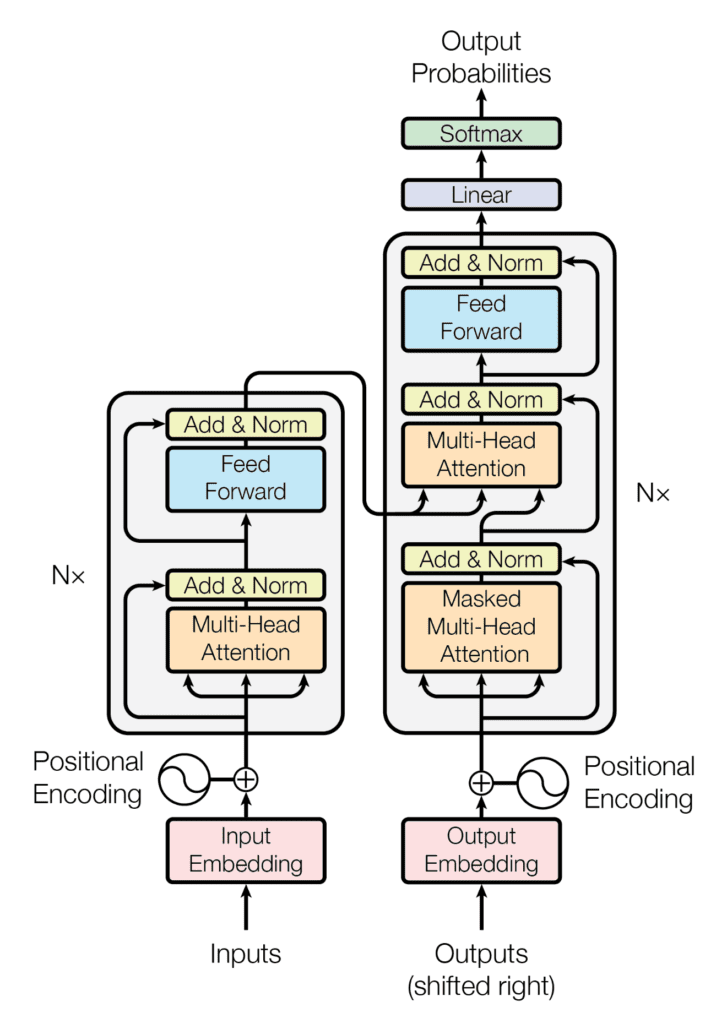

#  Input Sentences:

1. **Apple is good in taste.**  
2. **Apple is good for health.**  
3. **Apple is a fruit.**  
4. **Apple we can buy in food shop.**  
5. **Apple is launching the iPhone 17 in 2025.**

---

##  Goal: What does a Transformer do with these?

A **Transformer model** (like **BERT**, **GPT**, etc.) processes all these sentences and **figures out the different meanings of the word "Apple"** in each sentence using:

- **Self-Attention Mechanism**
- **Contextual Embeddings**

---

##  Step-by-Step Explanation

### 1. Tokenization

Each sentence is broken into **tokens** (usually words or subword units):




---

###  2. Embedding Layer

Each token is converted into a **vector** (a list of numbers), which represents the word's meaning.

For example:

```python
"Apple" → [0.12, -0.55, 1.23, ...]


###  3. Self-Attention Mechanism

The **self-attention** layer is the core innovation of the Transformer.

At each word/token, the model asks:

> ❓ “Which other words in the sentence are important for understanding this word?”

It calculates **attention scores** between every pair of words using **dot products** of query, key, and value vectors.

####  Example:

Take this sentence:

> **"Apple is launching the iPhone 17 in 2025."**

The Transformer computes attention for the word **"Apple"** with respect to:

- **"launching"** → high relevance  
- **"iPhone"** → very high relevance  
- **"2025"** → some relevance  
- **"is"**, **"the"** → low relevance

 Result: It understands "Apple" is acting like a **tech company**.

---

Now consider:

> **"Apple is good in taste."**

The model attends more to:

- **"good"**
- **"taste"**

 Result: It learns that "Apple" here is a **fruit**.

This mechanism works **automatically**, and **for every word**, in **every sentence**.

---

### 4. Contextual Understanding

One of the biggest advantages of Transformers is their ability to learn **contextual embeddings**.

That means the same word can have **multiple meanings** depending on the **surrounding words**.

####  Table Example:

| Sentence                                      | Meaning of "Apple"        |
|----------------------------------------------|----------------------------|
| Apple is good in taste.                      | 🍎 Fruit – related to food |
| Apple is good for health.                    | 🍎 Fruit – nutrition        |
| Apple is launching the iPhone 17 in 2025.    | 🏢 Company – tech launch    |
| Apple we can buy in food shop.               | 🍎 Fruit – marketplace      |

> In older models (like Word2Vec), "Apple" would have **one fixed meaning**.  
> In Transformers, "Apple" has **dynamic, context-aware meaning**.

This is why Transformers are so effective in tasks like:

- Machine Translation
- Text Classification
- Named Entity Recognition
- Question Answering

---

###  5. Parallel Processing

Traditional models like RNNs read input **one token at a time**:

```text
"I" → "am" → "going" → "to" → "school"

# Transformer 

## Encoder 

#  Passing the Sentence through a Transformer (Step-by-Step)

---

##  Input Sentence:



---

##  Step 1: Tokenization

We break the sentence into tokens. Let’s assume we use **Word-level tokenization** (for simplicity).




Each word is assigned a **unique index** from the vocabulary.




---

##  Step 2: Word Embeddings

We convert each token into a **fixed-size embedding vector** (e.g., 512 dimensions).

Example (dimension = 4 for simplicity):

| Token | Embedding Vector            |
|-------|------------------------------|
| The   | [0.12, -0.45, 1.22, 0.99]    |
| cat   | [0.65, 0.11, -0.77, 0.08]    |
| on    | [-0.34, 1.02, 0.13, 0.56]    |
| mat   | [0.91, -0.30, 0.44, 0.66]    |
| .     | [0.01, 0.03, -0.12, -0.06]   |

 These are **learned representations** of word meanings.

---

## Step 3: Positional Encoding

Since Transformers don't use RNNs or CNNs, they have **no sense of word order**.  
So we add **Positional Encoding** to give the model a sense of position.

 **Formula**:

For position \( pos \) and dimension \( i \):

$$
PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{\frac{2i}{d_{model}}}}\right)
$$

$$
PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{\frac{2i}{d_{model}}}}\right)
$$

Where:

- \( pos \) = position (0, 1, 2, ...)
- \( i \) = dimension index (0, 1, 2, ...)
- \( d_{model} \) = embedding size (e.g., 512)

---

### Example with \( d_{model} = 4 \)

Let’s compute Positional Encoding for 4 dimensions and 5 words:

| Position | PE (dim=0)   | PE (dim=1)   | PE (dim=2)         | PE (dim=3)         |
|----------|--------------|--------------|--------------------|--------------------|
| 0        | sin(0)       | cos(0)       | sin(0)             | cos(0)             |
| 1        | sin(1/10000⁰) | cos(1/10000⁰) | sin(1/10000⁰⋅⁵)   | cos(1/10000⁰⋅⁵)   |
| 2        | sin(2/10000⁰) | cos(2/10000⁰) | sin(2/10000⁰⋅⁵)   | cos(2/10000⁰⋅⁵)   |
| 3        | ...          | ...          | ...                | ...                |

_You can compute these using NumPy in code._


---

## Step 4: Add Word Embedding + Positional Encoding

The final input to the Transformer is:

$$
\text{Final Embedding} = \text{Word Embedding} + \text{Positional Encoding}
$$

This gives both:

- **Semantic Meaning** (from word embedding)
- **Word Order** (from position encoding)

---




#  Manual Positional Encoding + Final Input

We are processing this sentence using a **Transformer**:

**"The cat on mat ."**

---

## Step 4.1: Word Embeddings (Given)

Assume embedding size **d_model = 4**

| Token | Embedding Vector                   |
|-------|------------------------------------|
| The   | [0.12, -0.45, 1.22, 0.99]          |
| cat   | [0.65,  0.11, -0.77, 0.08]         |
| on    | [-0.34, 1.02,  0.13, 0.56]         |
| mat   | [0.91, -0.30,  0.44, 0.66]         |
| .     | [0.01,  0.03, -0.12, -0.06]        |

---

## Step 4.2: Manual Positional Encoding (d_model = 4)

Using the formulas:

$$
PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{\frac{2i}{d_{model}}}}\right)
\quad ; \quad
PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{\frac{2i}{d_{model}}}}\right)
$$

Use:

$$
d_{model} = 4
$$

So:

$$
10000^{0/4} = 1 \\
10000^{2/4} = 100
$$


Now compute PE(pos) for each position (rounded to 4 decimal places):

### PE(0) — Position: "The"

$$
[ \sin(0/1), \cos(0/1), \sin(0/100), \cos(0/100) ] = [0.0000, 1.0000, 0.0000, 1.0000]
$$

### PE(1) — Position: "cat"

$$
[ \sin(1), \cos(1), \sin(0.01), \cos(0.01) ] = [0.8415, 0.5403, 0.0100, 0.9999]
$$

### PE(2) — Position: "on"

$$
[ \sin(2), \cos(2), \sin(0.02), \cos(0.02) ] = [0.9093, -0.4161, 0.0200, 0.9998]
$$

### PE(3) — Position: "mat"

$$
[ \sin(3), \cos(3), \sin(0.03), \cos(0.03) ] = [0.1411, -0.9899, 0.0300, 0.9996]
$$

### PE(4) — Position: "."

$$
[ \sin(4), \cos(4), \sin(0.04), \cos(0.04) ] \approx [-0.7568, -0.6536, 0.0400, 0.9992]
$$


---

## Step 4.3: Final Input = Word Embedding + Positional Encoding

Add embedding vector + PE vector (element-wise):

### 🔹 "The"
\[
[0.12, -0.45, 1.22, 0.99] + [0.0000, 1.0000, 0.0000, 1.0000] = [0.1200, 0.5500, 1.2200, 1.9900]
\]

### 🔹 "cat"
\[
[0.65, 0.11, -0.77, 0.08] + [0.8415, 0.5403, 0.0100, 0.9999]=  [1.4915, 0.6503, -0.7600, 1.0799]
\]

### 🔹 "on"
\[
[-0.34, 1.02, 0.13, 0.56] + [0.9093, -0.4161, 0.0200, 0.9998] = [0.5693, 0.6039, 0.1500, 1.5598]
\]

### 🔹 "mat"
\[
[0.91, -0.30, 0.44, 0.66] + [0.1411, -0.9899, 0.0300, 0.9996] = [1.0511, -1.2899, 0.4700, 1.6596]
\]

### 🔹 "."
\[
[0.01, 0.03, -0.12, -0.06] + [-0.7568, -0.6536, 0.0400, 0.9992] = [-0.7468, -0.6236, -0.0800, 0.9392]
\]

---

## Final Input Vectors to Transformer

| Token | Final Input Vector                        |
|-------|--------------------------------------------|
| The   | [0.1200, 0.5500, 1.2200, 1.9900]           |
| cat   | [1.4915, 0.6503, -0.7600, 1.0799]          |
| on    | [0.5693, 0.6039, 0.1500, 1.5598]           |
| mat   | [1.0511, -1.2899, 0.4700, 1.6596]          |
| .     | [-0.7468, -0.6236, -0.0800, 0.9392]        |

---

These vectors are passed into the first **Transformer Encoder layer**, where **multi-head self-attention** begins.


# Attention Mechanism

#   Self-Attention Calculation on Final Embeddings

##  Final Input Vectors (After Positional Encoding)

| Token | Input Vector |
|-------|--------------|
| The   | [0.1200, 0.5500, 1.2200, 1.9900]  
| cat   | [1.4915, 0.6503, -0.7600, 1.0799]  
| on    | [0.5693, 0.6039, 0.1500, 1.5598]  
| mat   | [1.0511, -1.2899, 0.4700, 1.6596]  
| .     | [-0.7468, -0.6236, -0.0800, 0.9392]  

Let’s denote this matrix as **X** ∈ ℝ^{5×4}.

---

##  Step 5.0: Define Weights W_Q, W_K, W_V (4×4)

Assume simple projection matrices:



---
##  Step 5.2: Compute Q = X × W_Q

Since \( W_Q \) is the identity matrix \( I \), we have:

$$
Q = X \times W_Q = X
$$

Therefore, the Query matrix \( Q \) is:

\[
Q =
\begin{bmatrix}
\text{"The"} & : & [0.1200, \ 0.5500, \ 1.2200, \ 1.9900] \\
\text{"cat"} & : & [1.4915, \ 0.6503, \ -0.7600, \ 1.0799] \\
\text{"on"}  & : & [0.5693, \ 0.6039, \ 0.1500, \ 1.5598] \\
\text{"mat"} & : & [1.0511, \ -1.2899, \ 0.4700, \ 1.6596] \\
\text{"."}   & : & [-0.7468, \ -0.6236, \ -0.0800, \ 0.9392]
\end{bmatrix}
\]

---


### Q, K, V Calculation using Your Provided Embeddings

---

We'll use only the first 2 embeddings:

$
X =
\begin{bmatrix}
0.1200 & 0.5500 & 1.2200 & 1.9900 \\
1.4915 & 0.6503 & -0.7600 & 1.0799 \\
\end{bmatrix}
$

---

## Step 5.3: Define Projection Matrices

Let:

$
W_Q =
\begin{bmatrix}
1 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 \\
\end{bmatrix}
$

$
W_K =
\begin{bmatrix}
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 \\
\end{bmatrix}
$

$
W_V =
\begin{bmatrix}
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
\end{bmatrix}
$

---
##  Step 5.4: Compute $Q = X \cdot W_Q$

We are given:

###  Matrix $X$:

$$
X =
\begin{bmatrix}
0.1200 & 0.5500 & 1.2200 & 1.9900 \\
1.4915 & 0.6503 & -0.7600 & 1.0799
\end{bmatrix}
$$

###  Matrix $W_Q$:

$$
W_Q =
\begin{bmatrix}
1 & 0 & 1 & 0 \\
0 & 1 & 1 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 0 & 1
\end{bmatrix}
$$

---

###   Row 1 Calculation

**$Q_{1,1}$**

$$
Q_{1,1} = (0.1200 \times 1) + (0.5500 \times 0) + (1.2200 \times 0) + (1.9900 \times 0) = 0.1200
$$

**$Q_{1,2}$**

$$
Q_{1,2} = (0.1200 \times 0) + (0.5500 \times 1) + (1.2200 \times 0) + (1.9900 \times 0) = 0.5500
$$

**$Q_{1,3}$**

$$
Q_{1,3} = (0.1200 \times 1) + (0.5500 \times 1) + (1.2200 \times 0) + (1.9900 \times 0) = 0.6700
$$

**$Q_{1,4}$**

$$
Q_{1,4} = (0.1200 \times 0) + (0.5500 \times 0) + (1.2200 \times 1) + (1.9900 \times 1) = 3.2100
$$

---

### Row 2 Calculation

**$Q_{2,1}$**

$$
Q_{2,1} = (1.4915 \times 1) + (0.6503 \times 0) + (-0.7600 \times 0) + (1.0799 \times 0) = 1.4915
$$

**$Q_{2,2}$**

$$
Q_{2,2} = (1.4915 \times 0) + (0.6503 \times 1) + (-0.7600 \times 0) + (1.0799 \times 0) = 0.6503
$$

**$Q_{2,3}$**

$$
Q_{2,3} = (1.4915 \times 1) + (0.6503 \times 1) + (-0.7600 \times 0) + (1.0799 \times 0) = 2.1418
$$

**$Q_{2,4}$**

$$
Q_{2,4} = (1.4915 \times 0) + (0.6503 \times 0) + (-0.7600 \times 1) + (1.0799 \times 1) = 0.3199
$$

---

###  Final Result:

$$
Q =
\begin{bmatrix}
0.1200 & 0.5500 & 0.6700 & 3.2100 \\
1.4915 & 0.6503 & 2.1418 & 0.3199
\end{bmatrix}
$$


## Step 5.5: Compute K = X × W_K

$
K =
\begin{bmatrix}
0.1200 & 0.5500 & 1.2200 & 1.9900 \\
1.4915 & 0.6503 & -0.7600 & 1.0799 \\
\end{bmatrix}
\cdot
\begin{bmatrix}
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 \\
\end{bmatrix}
=
\begin{bmatrix}
0.5500 & 0.1200 & 1.2200 & 1.9900 \\
0.6503 & 1.4915 & -0.7600 & 1.0799 \\
\end{bmatrix}
$

---

## Step 5.6: Compute V = X × W_V

$
V =
\begin{bmatrix}
0.1200 & 0.5500 & 1.2200 & 1.9900 \\
1.4915 & 0.6503 & -0.7600 & 1.0799 \\
\end{bmatrix}
\cdot
\begin{bmatrix}
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
\end{bmatrix}
=
\begin{bmatrix}
1.2200 & 0.5500 & 0.1200 & 1.9900 \\
-0.7600 & 0.6503 & 1.4915 & 1.0799 \\
\end{bmatrix}
$

---

## 5.7 Final Q, K, V Outputs

```python


Q = [[0.1200, 0.5500, 1.3400, 1.9900],
     [1.4915, 0.6503, 0.7315, 1.0799]]

K = [[0.5500, 0.1200, 1.2200, 1.9900],
     [0.6503, 1.4915, -0.7600, 1.0799]]

V = [[1.2200, 0.5500, 0.1200, 1.9900],
     [-0.7600, 0.6503, 1.4915, 1.0799]]

---

##  Step 6.0: Scaled Dot-Product Attention

Given:

Q = 
\[
\begin{bmatrix}
0.1200 & 0.5500 & 1.3400 & 1.9900 \\
1.4915 & 0.6503 & 0.7315 & 1.0799 \\
\end{bmatrix}
\]

K = 
\[
\begin{bmatrix}
0.5500 & 0.1200 & 1.2200 & 1.9900 \\
0.6503 & 1.4915 & -0.7600 & 1.0799 \\
\end{bmatrix}
\]


We first transpose **K** to get $K^\top$:

$$
K^\top =
\begin{bmatrix}
0.5500 & 0.6503 \\
0.1200 & 1.4915 \\
1.2200 & -0.7600 \\
1.9900 & 1.0799 \\
\end{bmatrix}
$$

##  Step 6.1: Compute Attention Scores

To compute attention scores between the **Query** ($Q$) and **Key** ($K$), we use the **Scaled Dot-Product Attention** formula.

---
###  Formula

The attention score between the $i^{th}$ query vector $Q_i$ and the $j^{th}$ key vector $K_j$ is given by:

$$
\text{AttentionScore}_{i,j} = \frac{Q_i \cdot K_j^\top}{\sqrt{d_k}}
$$

---

### Explanation:

- $Q_i$: The query vector for the $i^{th}$ token (row of $Q$).
- $K_j$: The key vector for the $j^{th}$ token (row of $K$).
- $Q_i \cdot K_j^\top$: This is the **dot product** between $Q_i$ and $K_j$, which gives a scalar value representing how "similar" the query and key are.
- $d_k$: The **dimension** of the key (or query) vectors. In this example, the vector size is **4**, so:
  
  $$
  d_k = 4 \quad \Rightarrow \quad \sqrt{d_k} = 2
  $$

- The division by $\sqrt{d_k}$ is done to **prevent large dot product values**, which can make the softmax output extremely peaked and cause gradients to vanish during training. Scaling helps maintain a **stable gradient flow**.

###  Compute Raw Dot Products

Let’s compute $Q \cdot K^\top$ manually.

####  Row 1 of $Q$: $[0.1200, 0.5500, 1.3400, 1.9900]$

- With Column 1 of $K^\top$ ($K_1$):

$$
(0.1200)(0.5500) + (0.5500)(0.1200) + (1.3400)(1.2200) + (1.9900)(1.9900)
= 0.066 + 0.066 + 1.6348 + 3.9601 = \mathbf{5.7269}
$$

- With Column 2 of $K^\top$ ($K_2$):

$$
(0.1200)(0.6503) + (0.5500)(1.4915) + (1.3400)(-0.7600) + (1.9900)(1.0799)
= 0.078 + 0.8203 - 1.0184 + 2.1480 = \mathbf{2.0279}
$$

####  Row 2 of $Q$: $[1.4915, 0.6503, 0.7315, 1.0799]$

- With $K_1$:

$$
(1.4915)(0.5500) + (0.6503)(0.1200) + (0.7315)(1.2200) + (1.0799)(1.9900)
= 0.8203 + 0.078 + 0.8924 + 2.1480 = \mathbf{3.9387}
$$

- With $K_2$:

$$
(1.4915)(0.6503) + (0.6503)(1.4915) + (0.7315)(-0.7600) + (1.0799)(1.0799)
= 0.9705 + 0.9705 - 0.5559 + 1.1662 = \mathbf{2.5513}
$$

---

###  Raw Dot Product Matrix

$$
QK^\top =
\begin{bmatrix}
5.7269 & 2.0279 \\
3.9387 & 2.5513 \\
\end{bmatrix}
$$

---

###  Full Attention Score Matrix

We compute the matrix of all pairwise attention scores using matrix multiplication:

$$
\text{Scores} = \frac{Q \cdot K^\top}{\sqrt{d_k}} = \frac{Q \cdot K^\top}{2}
$$


$$
\text{AttentionScore}_{i,j} = \frac{Q_i \cdot K_j^\top}{\sqrt{d_k}}, \quad \text{where } d_k = 4 \Rightarrow \sqrt{d_k} = 2
$$


Let’s call this matrix $S$:

$$
S =
\begin{bmatrix}
\frac{Q_1 \cdot K_1^\top}{2} & \frac{Q_1 \cdot K_2^\top}{2} \\
\frac{Q_2 \cdot K_1^\top}{2} & \frac{Q_2 \cdot K_2^\top}{2}
\end{bmatrix}
$$
Let’s compute $Q \cdot K^\top$ manually.

####  Row 1 of $Q$: $[0.1200, 0.5500, 1.3400, 1.9900]$

- With Column 1 of $K^\top$ ($K_1$):

$$
(0.1200)(0.5500) + (0.5500)(0.1200) + (1.3400)(1.2200) + (1.9900)(1.9900)
= 0.066 + 0.066 + 1.6348 + 3.9601 = \mathbf{5.7269}
$$

- With Column 2 of $K^\top$ ($K_2$):

$$
(0.1200)(0.6503) + (0.5500)(1.4915) + (1.3400)(-0.7600) + (1.9900)(1.0799)
= 0.078 + 0.8203 - 1.0184 + 2.1480 = \mathbf{2.0279}
$$

####  Row 2 of $Q$: $[1.4915, 0.6503, 0.7315, 1.0799]$

- With $K_1$:

$$
(1.4915)(0.5500) + (0.6503)(0.1200) + (0.7315)(1.2200) + (1.0799)(1.9900)
= 0.8203 + 0.078 + 0.8924 + 2.1480 = \mathbf{3.9387}
$$

- With $K_2$:

$$
(1.4915)(0.6503) + (0.6503)(1.4915) + (0.7315)(-0.7600) + (1.0799)(1.0799)
= 0.9705 + 0.9705 - 0.5559 + 1.1662 = \mathbf{2.5513}
$$



This matrix $S$ tells us **how much attention** each query gives to each key. The higher the score, the more important that key is to the query.

---
###  Raw Dot Product Matrix

$$
QK^\top =
\begin{bmatrix}
5.7269 & 2.0279 \\
3.9387 & 2.5513 \\
\end{bmatrix}
$$

---

###  Scaled Attention Scores

Since $\sqrt{d_k} = 2$, divide all elements by 2:

$$
S = \frac{QK^\top}{2} =
\begin{bmatrix}
2.8635 & 1.0139 \\
1.9694 & 1.2757 \\
\end{bmatrix}
$$


---

##  Step 6.1: Apply Softmax to Attention Scores

 \$ \text{softmax}(S_i) = \frac{e^{S_i}}{\sum_j e^{S_j}} \$

This gives attention **weights** for each token to every other token.

Let’s denote the weights matrix as:

\[
\$ \text{Weights} =
\begin{bmatrix}
w_{11} & w_{12} \\
w_{21} & w_{22}
\end{bmatrix}
 \$ \]


### Softmax for Row 1:

$$
\text{softmax}([2.8635, 1.0139]) =
\left[
\frac{e^{2.8635}}{e^{2.8635} + e^{1.0139}},
\frac{e^{1.0139}}{e^{2.8635} + e^{1.0139}}
\right]
$$

- $e^{2.8635} \approx 17.53$, $e^{1.0139} \approx 2.756$

$$
\Rightarrow \text{Row 1} = [0.8645, 0.1355]
$$

### Softmax for Row 2:

$$
\text{softmax}([1.9694, 1.2757]) =
\left[
\frac{e^{1.9694}}{e^{1.9694} + e^{1.2757}},
\frac{e^{1.2757}}{e^{1.9694} + e^{1.2757}}
\right]
$$

- $e^{1.9694} \approx 7.164$, $e^{1.2757} \approx 3.581$

$$
\Rightarrow \text{Row 2} = [0.6668, 0.3332]
$$

---
###  Final Weights Matrix:

$$
\text{Weights} =
\begin{bmatrix}
0.8645 & 0.1355 \\
0.6668 & 0.3332 \\
\end{bmatrix}
$$

##  Step 6.2: Compute Final Attention Output

Given:

$$
V =
\begin{bmatrix}
1.2200 & 0.5500 & 0.1200 & 1.9900 \\
-0.7600 & 0.6503 & 1.4915 & 1.0799 \\
\end{bmatrix}
$$

Now compute $\text{Output} = \text{Weights} \cdot V$


\[
 \$
\text{Attention}(Q, K, V) = \text{softmax}\left( \frac{QK^T}{\sqrt{d_k}} \right) \cdot V \$

\]

\[
\$
\text{Output} =
\begin{bmatrix}
w_{11} & w_{12} \\
w_{21} & w_{22}
\end{bmatrix}
\cdot
\begin{bmatrix}
1.2200 & 0.5500 & 0.1200 & 1.9900 \\
-0.7600 & 0.6503 & 1.4915 & 1.0799
\end{bmatrix}
\$ \]


### Row 1 Output:

$$
0.8645 \cdot [1.2200, 0.5500, 0.1200, 1.9900] +
0.1355 \cdot [-0.7600, 0.6503, 1.4915, 1.0799]
$$

$$
= [1.0557, 0.4755, 0.1037, 1.7194] +
[-0.103, 0.0882, 0.2021, 0.1463]
= \mathbf{[0.9527, 0.5637, 0.3058, 1.8657]}
$$

### Row 2 Output:

$$
0.6668 \cdot [1.2200, 0.5500, 0.1200, 1.9900] +
0.3332 \cdot [-0.7600, 0.6503, 1.4915, 1.0799]
$$

$$
= [0.8135, 0.3667, 0.0800, 1.3269] +
[-0.2532, 0.2167, 0.4972, 0.3594]
= \mathbf{[0.5603, 0.5834, 0.5772, 1.6863]}
$$
This gives you **the final attention output vectors** per token.

---

###  Final Attention Output:

$$
\text{Output} =
\begin{bmatrix}
0.9527 & 0.5637 & 0.3058 & 1.8657 \\
0.5603 & 0.5834 & 0.5772 & 1.6863 \\
\end{bmatrix}
$$

##  Step 6.3: Add & LayerNorm

Add residual connection from original input:

\[
\$
  \text{Out}_1 = \text{LayerNorm}(\text{Input}_X + \text{AttentionOutput}) \$
\]

---

##  Step 6.4: Position-wise Feed-Forward Network

Each token is passed through a feed-forward network:

\[ 
\$ \text{FFN}(x) = \text{ReLU}(xW_1 + b_1)W_2 + b_2
\$ \]

Typically:
- $W_1 \in \mathbb{R}^{d_{\text{model}} \times d_{\text{ff}}}$
- $W_2 \in \mathbb{R}^{d_{\text{ff}} \times d_{\text{model}}}$
- Example: $d_{\text{model}} = 512$, $d_{\text{ff}} = 2048$

---

##  Step 6.5: Add & LayerNorm (Again)

Final output of block:

\[
\$ \text{Out}_2 = \text{LayerNorm}(\text{Out}_1 + \text{FFN}(Out_1))
 \$ \]

---

##  Step 6.6: Repeat for N Layers (e.g., 6)

You repeat this entire attention → FFN → residual flow for **N layers** (typically 6 or 12).

Each block further **refines** the token representations.

---

**Final Output of Encoder:**
Let final output be $Z \in \mathbb{R}^{T \times d_{\text{model}}}$

- For classification: use the first token (e.g., `[CLS]`)
- For encoder-decoder: pass $Z$ into the **decoder**

#  All Steps for Transformer Encoder 

1. **Tokenization** – Break the sentence `"The cat on mat."` into words and convert each word into a number (token ID).

2. **Word Embeddings** – Replace each token ID with a 4D vector that represents the meaning of the word.

3. **Positional Encoding** – Add a special vector to each word that tells its position in the sentence.

4. **Final Input Vectors** – Add the word vector and position vector together for each word.

5. **Q, K, V Projection** – Create three versions of the input (Q = Query, K = Key, V = Value) using weight matrices.

6. **Attention Calculation** – Compare each word with every other word to decide how much focus (attention) each word should get.

7. **Add & Normalize** – Add the attention result back to the input and normalize it (LayerNorm).

8. **Feed Forward Network** – Pass each word's vector through a mini neural network to process it further.

9. **Final Output** – Again add and normalize the result to get the final encoder output.

